In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
df = sns.load_dataset("titanic")
features = ['age', 'fare', 'sibsp', 'parch', 'pclass', 'sex', 'embarked']
X = df[features].copy()
y = df['survived']


In [2]:
X['age'] = X['age'].fillna(X['age'].median())
X['fare'] = X['fare'].fillna(X['fare'].median())
X['embarked'] = X['embarked'].fillna(X['embarked'].mode()[0])
X = pd.get_dummies(X, columns=['sex', 'embarked'], drop_first=True)
model = DecisionTreeClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring='accuracy'
)
print("K-Fold Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())


K-Fold Accuracy Scores: [0.7877095  0.76404494 0.80898876 0.75280899 0.7752809 ]
Mean Accuracy: 0.7777666185424643


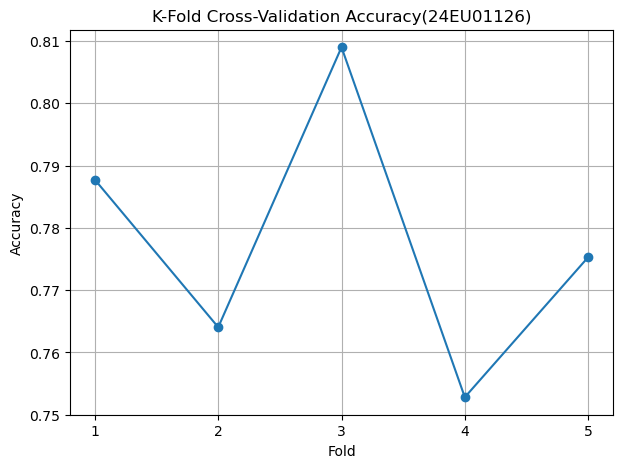

In [3]:
plt.figure(figsize=(7, 5))
plt.plot(
    range(1, 6),
    scores,
    marker='o'
)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("K-Fold Cross-Validation Accuracy(24EU01126)")
plt.xticks(range(1, 6))
plt.grid()
plt.show()


In [4]:
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid.fit(X, y)
print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)


Best Parameters: {'max_depth': 7, 'min_samples_split': 2}
Best Accuracy: 0.8148201619484026


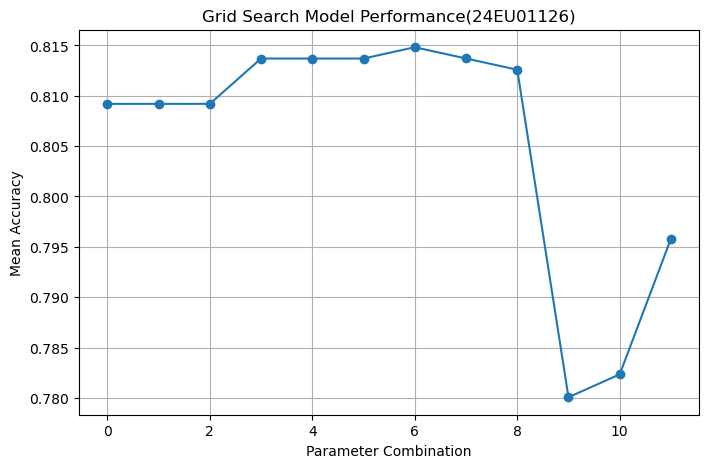

In [5]:
results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(len(results)),
    results['mean_test_score'],
    marker='o'
)
plt.xlabel("Parameter Combination")
plt.ylabel("Mean Accuracy")
plt.title("Grid Search Model Performance(24EU01126)")
plt.grid()
plt.show()
